## FLOPS Analysis ..


* FLOPs (Floating point Opeartions Per Second) measure the computational complexity of newural network by counting the number of floating-point operations executed
* High FLOPs indicates the more intensive computation and energy consumption..

In [8]:
!pip install -r requirements-extra.txt

In [9]:
from importlib.metadata import version
pkgs = [
    "thop",
    "torch",
]

for p in pkgs:
  print(f"{p} version: {version(p)}")

thop version: 0.1.1-2209072238
torch version: 2.9.0+cu126


## Simple Benchmark with fixed batch size

* forward pass only

In [ ]:
!jupyter nbconvert --to python ch04.ipynb


In [11]:
!touch ch04/__init__.py


mathplotlib version: 3.10.0
torch version: 2.9.0+cu126
tiktoken version 0.12.0
tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.0417, -0.4867, -1.5340,  ...,  0.3574,  0.5406, -0.7852],
         [-0.2591, -0.4835, -0.4902,  ..., -2.1452,  1.4574, -1.5724],
         [-1.6235,  0.4488,  0.5913,  ..., -1.5111, -0.5269, -1.3327],
         [-0.4389, -0.2879,  0.7726,  ..., -0.8388, -0.3378,  0.0329]],

        [[ 0.0417, -0.4867, -1.5340,  ...,  0.3574,  0.5406, -0.7852],
         [ 0.4757, -0.9158, -0.8114,  ..., -1.2287,  0.5310, -2.0623],
         [-0.9472,  0.3388, -0.2086,  ..., -0.9980, -0.4179, -0.8240],
         [-0.4388, -0.2660, -0.3324,  ..., -0.0027, -0.7659,  0.8341]]],
       grad_fn=<UnsafeViewBackward0>)
tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)
Mean
 tensor([[0.1324],
        [0.2170]], grad_fn=<M

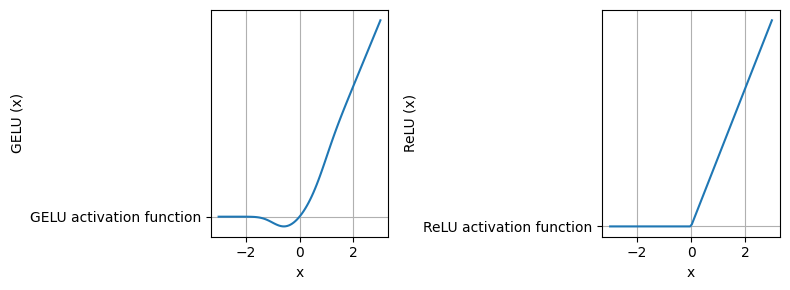

768
torch.Size([2, 3, 768])
layers.0.0.weight has gradient mean of 0.00020471324387472123
layers.1.0.weight has gradient mean of 0.0001231795467901975
layers.2.0.weight has gradient mean of 0.0007344745099544525
layers.3.0.weight has gradient mean of 0.0013871212722733617
layers.4.0.weight has gradient mean of 0.005026495084166527
layers.0.0.weight has gradient mean of 0.29920274019241333
layers.1.0.weight has gradient mean of 0.2749510407447815
layers.2.0.weight has gradient mean of 0.45466116070747375
layers.3.0.weight has gradient mean of 0.362958699464798
layers.4.0.weight has gradient mean of 1.763088583946228
Input shape:  torch.Size([2, 4, 768])
Output shape torch.Size([2, 4, 768])
Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])
Output batch:
 torch.Size([2, 4, 50257])
tensor([[[-0.1411,  0.2236, -0.2767,  ..., -0.3506,  0.2924, -0.4702],
         [-0.2609,  0.1129,  0.1309,  ...,  1.3413, -0.0512,  0.2110],
         [ 0.7960,  0.3855, -0.3036,

In [13]:
import torch
from thop import profile

from ch04.ch04 import GPTModel

BASE_CONFIG = {
    "vocab_size": 50257,       # Vocabualry size
    "context_length": 1024,   # context length
    "drop_rate":  0.0,        # Dropout rate
    "qkv_bias": True          # Query-key-value bias
}


model_configs = {
    "gpt-small (124M)": {"emb_dim": 768,"n_layers": 12, "n_heads": 12},
    "gpt_medium (355M)": {"emb_dim": 1024, "n_layer": 24, "n_heads": 16},
    "gpt-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

batch_size = 2
input_tensor = torch.randint(0, 50257, (batch_size, 1024)).to(device)

for size in model_configs:
  BASE_CONFIG.update(model_configs[size])

  model = GPTModel(BASE_CONFIG).bfloat16()
  model.to(device)

  # MACS = multiply-accumulate operations
  # MACS are typically counted as two FLOPS (one multiply and one accumulate)
  macs, params = profile(model, inputs=(input_tensor,), verbose=False)
  flops = 2*macs
  print(f"{size:18}: {flops:.1e} FLOPS")

  del model
  torch.cuda.empty_cache()

## Simple Bechmark and automatic batch size finding ...


* Forward pass only..

In [ ]:
for size in model_configs:
  print(f"\nProcessing {size}")
  config = BASE_CONFIG.copy()
  config.update(model_configs[size])

  min_batch_size = 1
  max_batch_size = None
  max_possible_batch_size = 4096

  while min_batch_size <= max_possible_batch_size:
    batch_size = (min_batch_size + max_possible_batch_size) // 2
    try:
      input_tensor = torch.randint(
          0, config["vocab_size"],
          (batch_size, config["context_length"]),
          device=device
      )
      model = GPTModel(config).bfloat16().to(device)

      # MACS = multiply-accumulate operations
      # MACS are typically counted as two (one multiply and one accumulate )
      macs, params = profile(model, inputs=(input_tensor,), verbose=False)
      flops = 2 * macs
      print(f" Batch size {batch_size}: {flops:.1e} FLOPS")

      # If successful , try larger batch size
      min_batch_size = batch_size + 1
      max_batch_size = batch_size

      # clean up
      del model, input_tensor
      torch.cuda.empty_cache()

    except RuntimeError as e:
      if "out of memory" in str(e):
        # Try smaller batch size  #
        max_possible_batch_size = batch_size - 1

        # Clean up
        try:
          del model, input_tensor
          torch.cuda.empty_cache()
        except NameError:
          pass
      else:
        raise e



Processing gpt-small (124M)
 Batch size 64: 9.7e+12 FLOPS
 Batch size 96: 1.5e+13 FLOPS
 Batch size 100: 1.5e+13 FLOPS
 Batch size 102: 1.5e+13 FLOPS
 Batch size 103: 1.6e+13 FLOPS

Processing gpt_medium (355M)
 Batch size 64: 4.0e+13 FLOPS
 Batch size 96: 6.0e+13 FLOPS
 Batch size 112: 7.0e+13 FLOPS

Processing gpt-large (774M)
 Batch size 64: 4.7e+13 FLOPS


## Benchmark with automatic batch size finding and model FLOP Utilization (MFU)
*
    Model FLOPs Utilization (MFU) explanation from the PaLM paper




* Forward and backward  pass

In [21]:
# THeoretical max (flops per second provided bty the GPU manufacturer)

flops_per_second = {
    "H100": {
        torch.float32: 51.22e12,      # 51.22 TFLOPs for FP32 on NVIDIA H100
        torch.float16: 204.9e12,      # 204.9 TFLOPs for FP16 on NVIDIA H100
        torch.bfloat16: 204.9e12
    },
    "L4": {
        torch.float32: 30.29e12,     # 30.29 TFLOPs for FP32 on NVIDIA L4
        torch.float16:  30.29e12,  # 30.29 TFLOPs for FP16 on NVIDIA L4
        torch.bfloat16: 30.29e12
    },
    "T4": {
        torch.float32: 8.1e12,     # 8.1 TFLOPs for FP32 on NVIDIA T4
        torch.float16:  65.13e12,  # 65.13 TFLOPs for FP16 on NVIDIA T4
        torch.bfloat16: 65.13e12
    },
    "A10G": {
        torch.float32:  31.52e12,     # 31.52 TFLOPs for FP32 on NVIDIA A10G
        torch.float16:  31.52e12,     # 31.52 TFLOPs for FP16 on NVIDIA A10G
        torch.bfloat16: 31.52e12
    },
    "A100":
    {
        torch.float32:   10.49e12,      # 19.49 TFLOPs for FP32 on NVIDIA A100
        torch.float16:   77.97e12,      # 77.97 TFLOPs for FP16 on NVIDIA A100
        torch.bfloat16:   77.97e12
    },
    "RTX_3080": {
        torch.float32: 29.77e12,  # 29.77 TFLOPs for FP32 on NVIDIA RTX 3080
        torch.float16: 29.77e12,  # 29.77 TFLOPs for FP16 on NVIDIA RTX 3080
        torch.bfloat16: 29.77e12
    },
     "RTX_3090": {
        torch.float32: 35.58e12,  # 35.58 TFLOPs for FP32 on NVIDIA RTX 3090
        torch.float16: 35.58e12,  # 35.58 TFLOPs for FP16 on NVIDIA RTX 3090
        torch.bfloat16: 35.58e12
    }

}




In [26]:
import time

def get_gpu_model(flops_per_second_dict):
  device_name = torch.cuda.get_device_name(0)
  for model in flops_per_second_dict.keys():
    if model in device_name:
      return model
  return "Unknown"   # Default if no mathcing model is found

gpu_model = get_gpu_model(flops_per_second)
print("GPU Model:", gpu_model)

if gpu_model != "Unknown":
  for size in model_configs:
    print(f"\nProcessing {size}")
    config = BASE_CONFIG.copy()
    config.update(model_configs[size])

    min_batch_size = 1
    max_batch_size = None
    max_possible_batch_size = 4096

    while min_batch_size <= max_possible_batch_size:
      batch_size = (min_batch_size + max_possible_batch_size) // 2
      try:
        input_tensor = torch.randint(
            0, config['vocab_size'],
            (batch_size, config["context_length"]),
            device=device
        )

        model = GPTModel(config).bfloat16().to(device)

        model.train()

        # Start timing
        torch.cuda.synchronize()
        start_time = time.time()

        # Forward & backward pass
        output = model(input_tensor)
        loss = output.sum()   # COmpute a dummy loss
        loss.backward()

        # End timing
        torch.cuda.synchronize()
        end_time = time.time()



        total_time_seconds = end_time - start_time

        # Calcuate te FLOPs for forward pass
        macs, params = profile(model, inputs=(input_tensor, ), verbose=False)
        flops_forward = 2 * macs   # Assuming one MAC equals two FLOPs

        # Estimate FLOPs for backward pass (typically 2x forward FLOPs)
        flops_backward = 2 * flops_forward

        # Total FLOPs forward + backward passes
        total_flops = flops_forward + flops_backward

        data_type = next(model.parameters()).dtype
        max_flops_per_second = flops_per_second[gpu_model].get(data_type, 0)

        # Compute tokens per second
        tokens_processed = batch_size * config["context_length"]
        tokens_per_second = tokens_processed / total_time_seconds

        # Compute FLOPs per token
        flops_per_token = total_flops / tokens_processed

        # Compute the theoretical max tokens per second
        if flops_per_token > 0:
          theoretical_max_tokens_per_second  = max_flops_per_second / flops_per_token
        else:
          theoretical_max_tokens_per_second = 0   # Avoid division by zero


        # Compute MFU
        if theoretical_max_tokens_per_second > 0:
          mfu = tokens_per_second / theoretical_max_tokens_per_second
        else:
          mfu = 0   # Avoid division by zero

        print(f" Batch size {batch_size}: Tokens/sec: {tokens_per_second:.2f}, MFU: {mfu:.4f}")


        # IF sucessful try larger batch_Size
        min_batch_size = batch_size + 1
        max_batch_size = batch_size

        # Clean up
        del model, input_tensor , output, loss
        torch.cuda.empty_cache()

      except RuntimeError as e:
        if "out of memory" in str(e).lower():
          # Try smaller batch size
          max_possible_batch_size = batch_size - 1

          # Clean up
          try:
            del model , input_tensor
            torch.cuda.empty_cache()
          except NameError:
            pass
        else:
          raise e
else:
  print("Unknwon model. Please update the flops_per_second dictionary with your GPU information.")

GPU Model: T4

Processing gpt-small (124M)
 Batch size 2: Tokens/sec: 4679.71, MFU: 0.0319
 Batch size 3: Tokens/sec: 4577.08, MFU: 0.0312

Processing gpt_medium (355M)
 Batch size 4: Tokens/sec: 1076.06, MFU: 0.0300

Processing gpt-large (774M)
 Batch size 4: Tokens/sec: 968.37, MFU: 0.0320

Processing gpt-xl (1558M)


* a value of 1.0 is best (equal to 100%)

* Note that the bathc sizes are smaller than previously becaus we also carry out backward pass, here which is more memory-intesive.